# Import Packages (Enhanced model)

In [1]:
import sys
print(sys.executable)

c:\Users\xin37\github\CNN-LSTM-model-for-energy-usage-forecasting-1\venv\Scripts\python.exe


In [119]:
# univariate multi-step lstm for the power usage dataset

import time

# Start counting notebook running time
time_start = time.time()

import numpy as np
import tensorflow as tf
# Set all random seeds for the program (Python, NumPy, and TensorFlow)
tf.keras.utils.set_random_seed(1)

import pandas as pd
from  IPython.display import display, Image
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

from keras.models import Sequential
from keras.layers import Dense, Flatten, LSTM, RepeatVector, TimeDistributed, Dropout
from keras.layers import Conv1D, MaxPooling1D, BatchNormalization
from keras.callbacks import EarlyStopping
from keras.regularizers import l2
from keras.utils import plot_model
import seaborn as sns
import matplotlib.pyplot as plt

In [120]:
import sklearn
import keras
import pandas as pd
from sklearn.preprocessing import StandardScaler
from time import strftime
current_time = strftime("%Y-%m-%d-%H-%M-%S")
print('current time: ', current_time)
print('numpy version: ', np.__version__)
print('tensorflow version: ', tf.__version__)
print('pandas version: ', pd.__version__)
print('scikit-learn version: ', sklearn.__version__)
print('keras version: ', keras.__version__)

current time:  2026-04-16-03-42-45
numpy version:  2.4.4
tensorflow version:  2.21.0
pandas version:  3.0.2
scikit-learn version:  1.8.0
keras version:  3.14.0


# Import Data¶
## Daily power data of all campus buildings of IIT Delhi

In [121]:
%%time
import pandas as pd
import numpy as np
import os

# Check if file exists and load it
path = 'C:\\Users\\xin37\\github\\CNN-LSTM-model-for-energy-usage-forecasting-1\\data\\cold_source_control_dataset.csv'
if not os.path.exists(path):
    raise FileNotFoundError(f"❌ File not found: {path}")

df = pd.read_csv(path, header=0, encoding='utf-8')

# Clean column names: strip whitespace and fix encoding issues
df.columns = (
    df.columns
    .str.strip()
    .str.replace("Â°", "°", regex=False)
    .str.replace("Â",  "",  regex=False)
)

# Parse 'Timestamp' column to datetime, assuming day-first format and coercing errors to NaT
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='ISO8601', errors='coerce')

# Check if parsing worked
print(f"Timestamp dtype : {df['Timestamp'].dtype}")
bad_ts = df['Timestamp'].isna().sum()
if bad_ts > 0:
    print(f"⚠️  {bad_ts} Timestamp(s) failed → NaT. Sample bad rows:")
    print(df[df['Timestamp'].isna()].head())
else:
    print("All timestamps parsed successfully.")

# Set 'Timestamp' as index for time series operations
df = df.set_index('Timestamp')

# Remove duplicate timestamps
dupes = df.index.duplicated().sum()
if dupes > 0:
    print(f"⚠️  Removed {dupes} duplicate timestamp row(s).")
    df = df[~df.index.duplicated(keep='first')]

# Sort by index to ensure correct time order
df = df.sort_index()

# Check for regularity of timestamps by analyzing time differences
time_diffs = df.index.to_series().diff().dropna()
dominant_freq = time_diffs.mode()[0]
irregular = (time_diffs != dominant_freq).sum()

print(f"\nDominant sampling interval : {dominant_freq}")
if irregular > 0:
    print(f"{irregular} irregular gap(s) detected — consider resampling.")
else:
    print(f"Timestamps are perfectly regular.")

df = df.drop(columns=['Output'], errors='ignore')

# Summary of the cleaned dataset
print(f"\nShape          : {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Date range     : {df.index.min()}  →  {df.index.max()}")
print(f"Missing values : {df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().any().any() else 'None ✅'}")
print(f"\nData types:\n{df.dtypes}")

display(df.head())
display(df.tail())
display(df.describe())

Timestamp dtype : datetime64[us]
All timestamps parsed successfully.

Dominant sampling interval : 0 days 01:00:00
Timestamps are perfectly regular.

Shape          : 3,498 rows × 10 cols
Date range     : 2025-01-01 00:00:00  →  2025-05-26 17:00:00
Missing values : None ✅

Data types:
Server_Workload(%)                    float64
Inlet_Temperature(°C)                 float64
Outlet_Temperature(°C)                float64
Ambient_Temperature(°C)               float64
Cooling_Unit_Power_Consumption(kW)    float64
Chiller_Usage(%)                      float64
AHU_Usage(%)                          float64
Total_Energy_Cost($)                  float64
Temperature_Deviation(°C)             float64
Cooling_Strategy_Action                   str
dtype: object


,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Cooling_Strategy_Action
Timestamp,,,,,,,,,,
2025-01-01 00:00:00,100.000000,24.726323,28.469324,21.424454,0.98,94.205859,45.462911,0.09,2.58,Reduce AHU
2025-01-01 01:00:00,87.358993,23.085262,29.854364,26.420271,0.95,85.776996,53.185858,0.10,2.42,Eco Mode
2025-01-01 02:00:00,19.313800,16.288791,23.381846,21.452172,0.43,28.148672,40.833469,0.06,2.55,Eco Mode
2025-01-01 03:00:00,41.406680,19.217280,24.323699,19.200412,0.61,49.300227,42.490922,0.08,4.80,Boost All
2025-01-01 04:00:00,49.514889,19.991740,23.205543,26.768503,0.69,49.656127,58.100890,0.10,2.77,Eco Mode


,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Cooling_Strategy_Action
Timestamp,,,,,,,,,,
2025-05-26 13:00:00,66.295603,22.909311,28.562760,19.708427,0.77,68.573840,44.403540,0.07,4.29,Eco Mode
2025-05-26 14:00:00,74.390242,21.284547,26.976109,27.882486,0.91,81.462991,51.526953,0.09,3.88,Eco Mode
2025-05-26 15:00:00,80.768533,22.457125,27.295623,27.837341,0.86,74.811266,52.964832,0.08,3.84,Maintain
2025-05-26 16:00:00,74.088522,21.278572,27.195434,23.366406,0.80,71.262443,46.445041,0.09,0.63,Boost All
2025-05-26 17:00:00,27.628318,17.750417,26.031466,24.316188,0.43,22.006582,50.761180,0.03,0.32,Reduce AHU


,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C)
count,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000
mean,65.210630,21.525187,26.492562,23.985334,0.761498,65.184674,48.002691,0.087430,2.305269
std,19.357733,2.185514,2.922662,2.863748,0.159458,19.619440,6.402203,0.024231,1.698664
min,10.000000,15.000000,16.282475,18.000000,0.330000,20.000000,31.092931,0.030000,0.000000
25%,51.567063,19.999580,24.500078,21.979872,0.650000,50.937388,43.518808,0.070000,0.950000
50%,65.639304,21.524394,26.495368,23.976287,0.760000,65.464146,48.049176,0.090000,1.960000
75%,79.528495,23.085253,28.456507,25.918209,0.880000,80.109679,52.339698,0.100000,3.310000
max,100.000000,27.965248,35.775612,34.375385,1.110000,100.000000,70.521581,0.160000,10.380000


CPU times: total: 46.9 ms
Wall time: 58 ms


In [122]:
def detect_outliers_iqr(df, cols):
    outlier_flags = pd.DataFrame(index=df.index)
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outlier_flags[col + '_outlier'] = ((df[col] < lower) | (df[col] > upper))
    
    return outlier_flags

num_cols = df.select_dtypes(include=["float64", "int64"]).columns
outliers = detect_outliers_iqr(df, num_cols)

print(f"\nOutlier summary (IQR method):", outliers.sum())


Outlier summary (IQR method): Server_Workload(%)_outlier                     0
Inlet_Temperature(°C)_outlier                  9
Outlet_Temperature(°C)_outlier                13
Ambient_Temperature(°C)_outlier               18
Cooling_Unit_Power_Consumption(kW)_outlier     0
Chiller_Usage(%)_outlier                       0
AHU_Usage(%)_outlier                          12
Total_Energy_Cost($)_outlier                  35
Temperature_Deviation(°C)_outlier             34
dtype: int64


## Perform one hot encoding

In [123]:
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Perform the encoding
df_encoded = pd.get_dummies(df, columns=['Cooling_Strategy_Action'], prefix='Action')

# Convert Boolean columns to integers
action_cols = df_encoded.filter(regex='^Action_').columns
df_encoded[action_cols] = df_encoded[action_cols].astype(int)

# Display the first 10 rows of the encoded columns
df_encoded[action_cols].head(10)

df = df_encoded

print("Columns currently in df:", df.columns.tolist())
display(df.head(10))

Columns currently in df: ['Server_Workload(%)', 'Inlet_Temperature(°C)', 'Outlet_Temperature(°C)', 'Ambient_Temperature(°C)', 'Cooling_Unit_Power_Consumption(kW)', 'Chiller_Usage(%)', 'AHU_Usage(%)', 'Total_Energy_Cost($)', 'Temperature_Deviation(°C)', 'Action_Boost All', 'Action_Eco Mode', 'Action_Increase Chiller', 'Action_Maintain', 'Action_Reduce AHU']


,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Action_Boost All,Action_Eco Mode,Action_Increase Chiller,Action_Maintain,Action_Reduce AHU
Timestamp,,,,,,,,,,,,,,
2025-01-01 00:00:00,100.000000,24.726323,28.469324,21.424454,0.98,94.205859,45.462911,0.09,2.58,0,0,0,0,1
2025-01-01 01:00:00,87.358993,23.085262,29.854364,26.420271,0.95,85.776996,53.185858,0.10,2.42,0,1,0,0,0
2025-01-01 02:00:00,19.313800,16.288791,23.381846,21.452172,0.43,28.148672,40.833469,0.06,2.55,0,1,0,0,0
2025-01-01 03:00:00,41.406680,19.217280,24.323699,19.200412,0.61,49.300227,42.490922,0.08,4.80,1,0,0,0,0
2025-01-01 04:00:00,49.514889,19.991740,23.205543,26.768503,0.69,49.656127,58.100890,0.10,2.77,0,1,0,0,0
2025-01-01 05:00:00,50.221896,19.073444,22.237347,27.583655,0.69,49.052331,58.551611,0.07,3.58,1,0,0,0,0
2025-01-01 06:00:00,36.096725,18.655844,23.007473,18.000000,0.50,40.129626,35.562764,0.06,6.00,0,0,0,1,0
2025-01-01 07:00:00,53.263935,19.478006,22.656099,23.431237,0.70,59.689791,45.399355,0.09,0.57,1,0,0,0,0
2025-01-01 08:00:00,95.953804,24.535218,33.834061,23.863867,0.96,93.722934,42.841288,0.13,0.14,0,0,0,0,1


# Visualize sample data

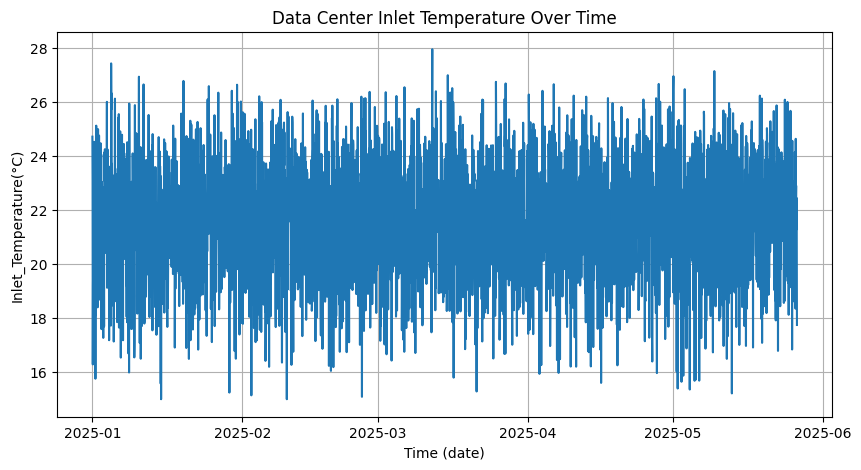

CPU times: total: 141 ms
Wall time: 134 ms


In [124]:
%%time
fig = plt.figure(figsize=(10, 5));
plt.plot(df.index, df['Inlet_Temperature(°C)']) 

plt.xlabel('Time (date)')
plt.ylabel('Inlet_Temperature(°C)')
plt.title('Data Center Inlet Temperature Over Time')
plt.grid(True) # Added for better readability
plt.show()

# Split a dataset into train/test sets

In [165]:
from sklearn.preprocessing import MinMaxScaler

# Run this before scaling/splitting
df['Hour_Sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['Hour_Cos'] = np.cos(2 * np.pi * df.index.hour / 24)

n_input  = 24         # Look back 6 hours
n_output = 1         # Predict next 1 hour
test_size = 24 * 7   # Last 1 week for testing

# Feature columns for training 
action_cols = [col for col in df.columns if col.startswith('Action_')]
FEATURE_COLS = [
    'Server_Workload(%)',
    'Cooling_Unit_Power_Consumption(kW)',
    'Chiller_Usage(%)',
    'AHU_Usage(%)',
    'Ambient_Temperature(°C)'
] + action_cols +['Hour_Sin', 'Hour_Cos']

TARGET_COL = 'Inlet_Temperature(°C)'

# 3. Create Sliding Windows (Crucial for CNN-LSTM)
# This turns a flat list into sequences: [t-6, t-5, t-4, t-3, t-2, t-1] -> [t]
def create_sequences(X, y, n_input, n_output):
    X_seq, y_seq = [], []

    for i in range(len(X) - n_input - n_output + 1):
        X_seq.append(X[i : i + n_input])
        y_seq.append(y[i + n_input : i + n_input + n_output])

    return np.array(X_seq), np.array(y_seq).squeeze()

# 4. Split and Scale Function
def prepare_data(data, test_size_hours):
    split_idx = len(data) - test_size_hours
    
    # Split into Train and Test sets
    train_df = data.iloc[:split_idx]
    test_df = data.iloc[split_idx:]
    
    # Scale Features
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(train_df[FEATURE_COLS])
    X_test_scaled = scaler.transform(test_df[FEATURE_COLS])
    
    target_scaler = MinMaxScaler()

    y_train_scaled = target_scaler.fit_transform(train_df[[TARGET_COL]])
    y_test_scaled  = target_scaler.transform(test_df[[TARGET_COL]])
    
    # Create Sequences
    X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, n_input, n_output)
    X_test, y_test = create_sequences(X_test_scaled, y_test_scaled, n_input, n_output)
    
    return X_train, y_train, X_test, y_test, scaler, target_scaler, X_train_scaled, X_test_scaled

# Execute
X_train, y_train, X_test, y_test, scaler, target_scaler, X_train_scaled, X_test_scaled  = prepare_data(df, test_size)

# Verify Shapes
print(f"X_train shape: {X_train.shape}") # Should be (Samples, 6, Features)
print(f"y_train shape: {y_train.shape}") # Should be (Samples, 1)

X_train shape: (3306, 24, 12)
y_train shape: (3306,)


# Define function for building model
In this model architecture, a one-dimensional convolutional neural network (1D CNN) is used to read and encode the input sequence. An LSTM network is then used as a decoder to make ode-step prediction for each value in the output sequence.

In [166]:
# build and train the model
def build_model(X_train_data, y_train_data, X_val_data, y_val_data):

    n_input = X_train_data.shape[1]
    n_features = X_train_data.shape[2]

    early_stop = EarlyStopping(
        monitor='val_loss', 
        patience=8, 
        restore_best_weights=True # THIS IS THE MOST IMPORTANT LINE
    )

    # define model
    model = Sequential([
        #-------CNN-------
        Conv1D(64, 3, activation='relu', padding='same', input_shape=(n_input, n_features)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        # Dropout(0.3),
        #-------CNN-------
        #-------LSTM-------
        LSTM(64, activation='tanh', return_sequences=False),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)
        #-------LSTM-------
    ])

    model.compile(loss='mae', optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005))
    model.summary()

    # fit network and save the history
    training_history = model.fit(
        X_train_data, y_train_data, 
        epochs=100, 
        batch_size= 32, 
        verbose= 1, 
        validation_data=(X_val_data, y_val_data), 
        callbacks=[early_stop]
        )

    return model, training_history

# Define function for evaluating model

In [167]:
def evaluate_model(X_train_full, X_test_full, n_input, model):
    buffer = X_train_full[-n_input:].copy()
    predictions = []

    for i in range(len(X_test_full)):
        x_in = buffer.reshape(1, n_input, buffer.shape[1])
        yhat = model.predict(x_in, verbose=0)
        predictions.append(float(yhat[0, 0]))

        new_row = X_test_full[i].reshape(1, -1) 
        buffer = np.vstack([buffer[1:], new_row])

    return np.array(predictions)

# Train model and make predictions

In [168]:
%%time
import tensorflow as tf

# clear old model from memory
tf.keras.backend.clear_session()

# prepare data
X_train, y_train, X_test, y_test, scaler, target_scaler, X_train_scaled, X_test_scaled = prepare_data(df, test_size)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

# split validation
val_size = int(len(X_train) * 0.2)

X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

# train model
model, training_history = build_model(X_tr, y_tr, X_val, y_val)

# prediction (IMPORTANT: use 2D scaled data)
predictions_scaled = evaluate_model(X_train_scaled, X_test_scaled, n_input, model)

# inverse transform
predictions_celsius = target_scaler.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()

# align ground truth
actual_celsius = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

print("Predictions:", len(predictions_celsius))

X_train: (3306, 24, 12)
y_train: (3306,)


c:\Users\xin37\github\CNN-LSTM-model-for-energy-usage-forecasting-1\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 24, 64)         │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,761 (147.50 KB)

 Trainable params: 37,633 (147.00 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.2106 - val_loss: 0.2592
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1624 - val_loss: 0.2160
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1530 - val_loss: 0.1793
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1478 - val_loss: 0.1658
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1440 - val_loss: 0.1475
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1427 - val_loss: 0.1457
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1420 - val_loss: 0.1491
Epoch 8/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1384 - val_loss: 0.1430
Epoch 9/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1378 - val_loss: 0.1440
Epoch 10/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1364 - val_loss: 0.1446
Epoch 11/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1349 - val_loss: 0.1467
Epoch 12/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.

# Visualize model architecture

In [ ]:
from IPython.display import Image, display
from tensorflow.keras.utils import plot_model

# model is already built, no need to call build_model again
# just plot and display directly

plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
display(Image(filename='model_architecture.png'))

# Compare actual and predicted values

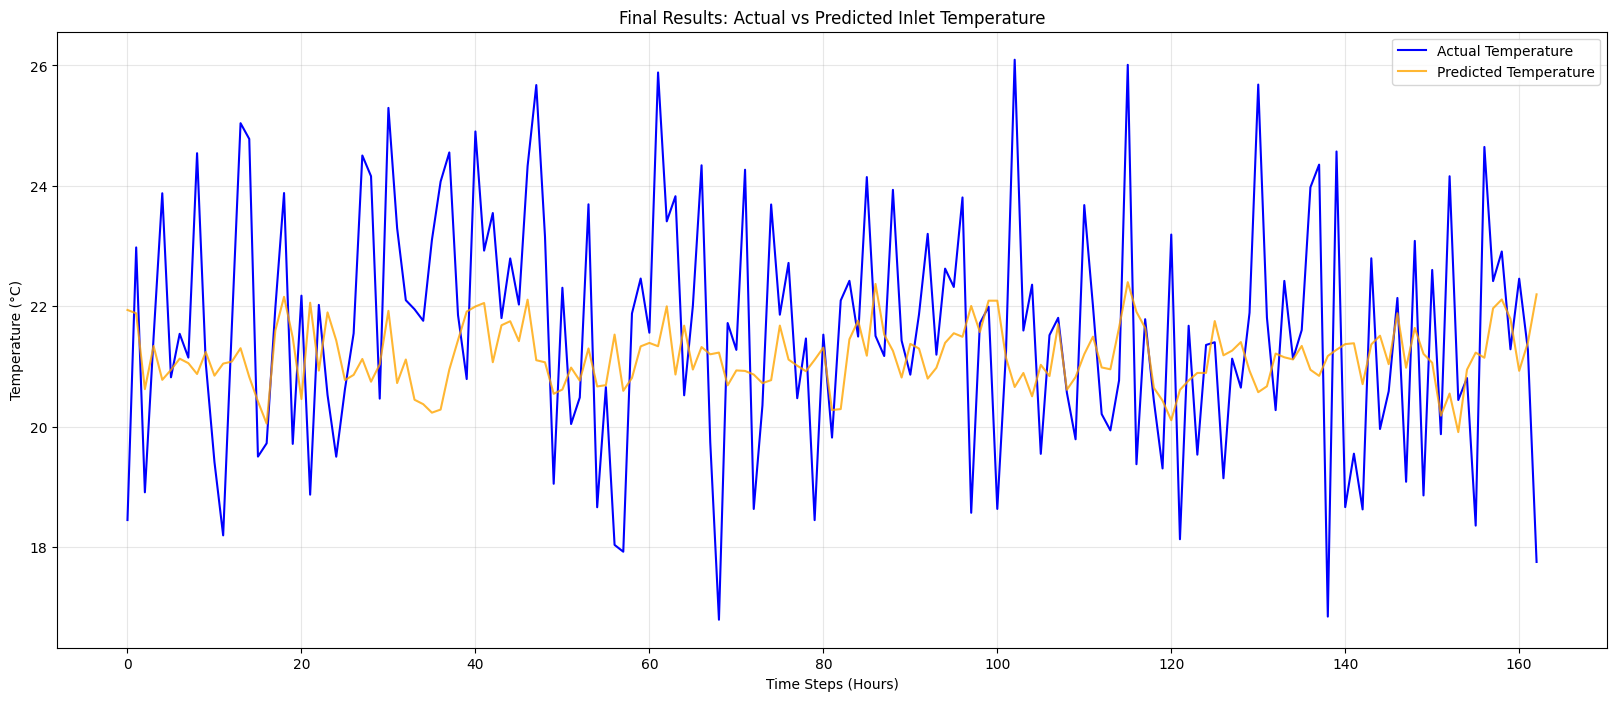

MAE: 1.6186 °C
RMSE: 2.0711 °C


In [163]:
min_len = min(len(actual_celsius), len(predictions_celsius))
final_actual = actual_celsius[:min_len]
final_pred = predictions_celsius[:min_len]

def plot_results(actual, predicted):
    plt.figure(figsize=(20, 8))
    plt.plot(actual, label='Actual Temperature', color='blue', linewidth=1.5)
    plt.plot(predicted, label='Predicted Temperature', color='orange', alpha=0.8, linewidth=1.5)
    plt.title('Final Results: Actual vs Predicted Inlet Temperature')
    plt.ylabel('Temperature (°C)')
    plt.xlabel('Time Steps (Hours)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the plot with the Celsius variables
plot_results(final_actual, final_pred)

# --- 4. Accuracy Check ---
from sklearn.metrics import mean_absolute_error, mean_squared_error
print(f"MAE: {mean_absolute_error(final_actual, final_pred):.4f} °C")
print(f"RMSE: {np.sqrt(mean_squared_error(final_actual, final_pred)):.4f} °C")

# RMSE for all sequences

In [102]:
time_end = time.time()
print("Notebook run time: {:.0f} seconds".format(time_end - time_start))

Notebook run time: 3442 seconds


## Performance metric for the baseline model (CNN-LSTM) and Models training loss and validation loss

Root Mean Squared Error (RMSE): 2.07 °C
Mean Absolute Error (MAE): 1.62 °C
R-squared Score (R2): -0.08


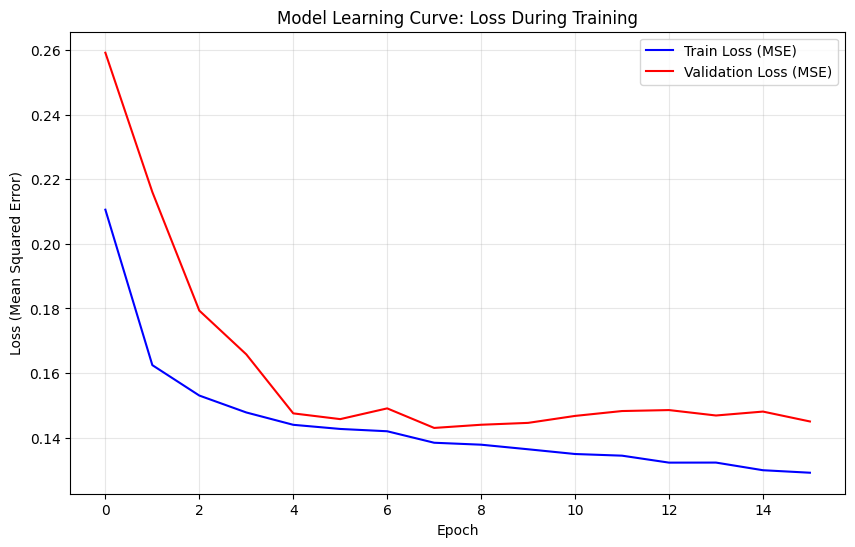

In [169]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

def return_performance_metrics(actual_vals, predicted_vals):
    rmse = np.sqrt(mean_squared_error(actual_vals, predicted_vals))
    mae = mean_absolute_error(actual_vals, predicted_vals)
    r2 = r2_score(actual_vals, predicted_vals)
    
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f} °C")
    print(f"Mean Absolute Error (MAE): {mae:.2f} °C")
    print(f"R-squared Score (R2): {r2:.2f}")
    
    return rmse, mae, r2

# Use the variables we aligned in the previous cell
# final_actual and final_pred are the Celsius versions
metrics = return_performance_metrics(final_actual, final_pred)

# --- Training Loss Plot ---
plt.figure(figsize=(10, 6))
# Using the global training_history object
plt.plot(training_history.history['loss'], label='Train Loss (MSE)', color='blue')
plt.plot(training_history.history['val_loss'], label='Validation Loss (MSE)', color='red')
plt.title('Model Learning Curve: Loss During Training')
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()